# Import Packages

In [14]:
import mne
from mne.preprocessing import ICA

# Load Data

In [17]:
raw = mne.io.read_raw_gdf("./../data/A01T.gdf", preload = True)
raw.set_channel_types({"EOG-left": "eog", "EOG-central": "eog", "EOG-right": "eog"})
raw.plot()
raw

Extracting EDF parameters from /home/jshen/Projects/Summer 2025 Deep Learning/EEG Motor Imagery DL/data/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/home/jshen/miniconda3/envs/Summer2025DL/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>

# Preprocessing

## Band Pass Filter

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_25063/1265145491.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd().plot()
/home/jshen/miniconda3/envs/Summer2025DL/lib/python3.13/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


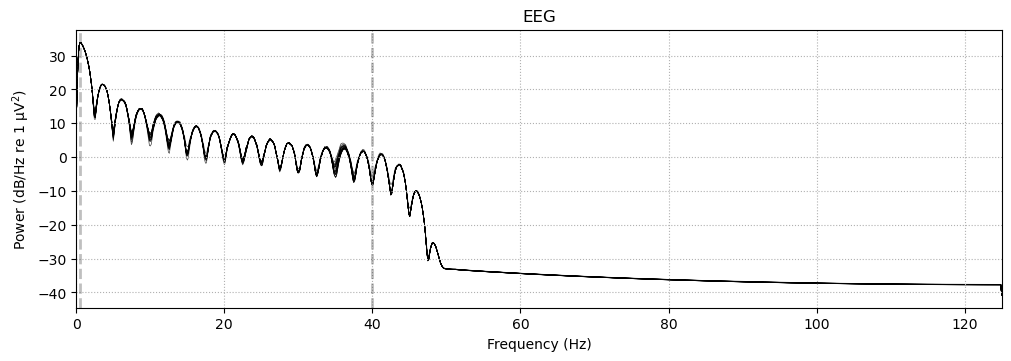

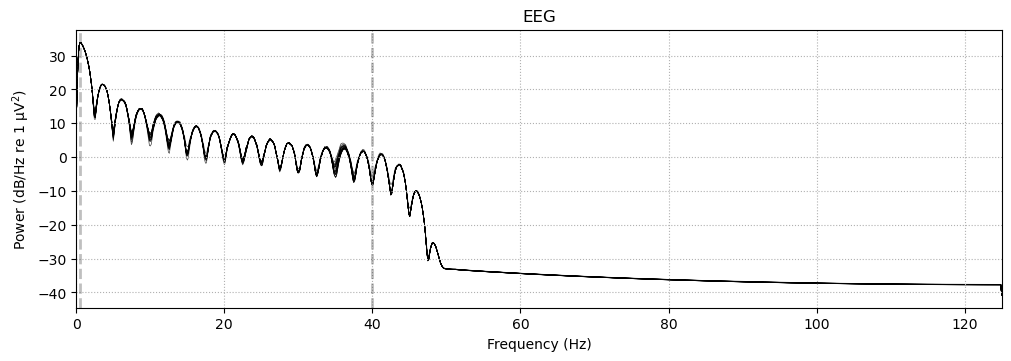

In [ ]:
# Band Pass Filter (0.5 - 40 Hz)
# 50Hz Notch Filter already applied during data collection
raw.filter(l_freq = 0.5, h_freq = 40.0)

## ICA

In [4]:
n_EEG_channels = sum(1 for ch in raw.info["ch_names"] if ch.startswith("EEG"))
ica = ICA(n_components = n_EEG_channels, random_state = 42)
ica.fit(raw)
ica

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 22 components
Fitting ICA took 20.2s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,38 iterations on raw data (672528 samples)
ICA components,22
Available PCA components,22
Channel types,eeg
ICA components marked for exclusion,—


In [5]:
eog_indices, eog_scores = ica.find_bads_eog(raw)
ica.exclude = eog_indices
ica.apply(raw)

Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB 

<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>

## Epoch Data by Events

In [6]:
raw.plot()

Using qt as 2D backend.


QStandardPaths: wrong permissions on runtime directory /run/user/1000/, 0755 instead of 0700
